In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 读取之前清洗好的 CSV 文件
df = pd.read_csv('../data/cleaned/online_retail_cleaned.csv')

# 转换日期格式
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 查看数据基本信息
print(df.info())
print(df.head())

# 选择分析所需的参考日期（用数据中最大日期 + 1天）
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"参考日期: {reference_date}")

# 计算每个用户的 RFM
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'Invoice': 'nunique',  # Frequency（去重订单数）
    'TotalAmount': 'sum'   # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalAmount': 'Monetary'
})

# 查看结果
print(rfm.head())
print(f"用户总数: {len(rfm)}")

# 给 RFM 打分（1-5分）
# 使用分位数（百分位数）打分
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])  # Recency 越小分越高
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# 将分数转为数值类型
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

# 计算总分（可以加权，这里简单相加）
rfm['RFM_Score'] = rfm['R_Score'] + rfm['F_Score'] + rfm['M_Score']

print(rfm.head())
print(rfm['R_Score'].head(10))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 406827 entries, 0 to 406826
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      406827 non-null  object        
 1   StockCode    406827 non-null  object        
 2   Description  406827 non-null  object        
 3   Quantity     406827 non-null  int64         
 4   InvoiceDate  406827 non-null  datetime64[ns]
 5   Price        406827 non-null  float64       
 6   Customer ID  406827 non-null  float64       
 7   Country      406827 non-null  object        
 8   is_cancel    406827 non-null  bool          
 9   TotalAmount  406827 non-null  float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 28.3+ MB
None
  Invoice StockCode                          Description  Quantity  \
0  536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1  536365     71053                  WHITE METAL LANT

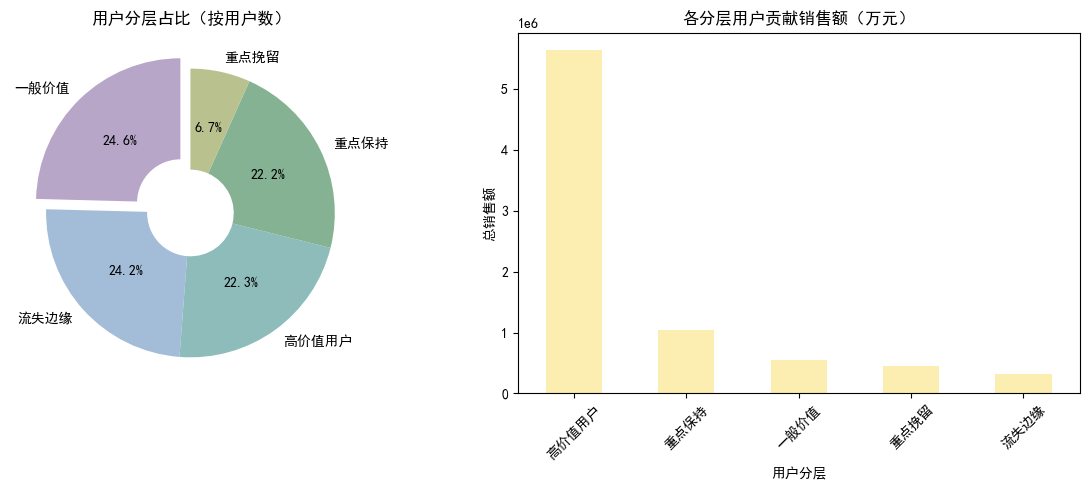

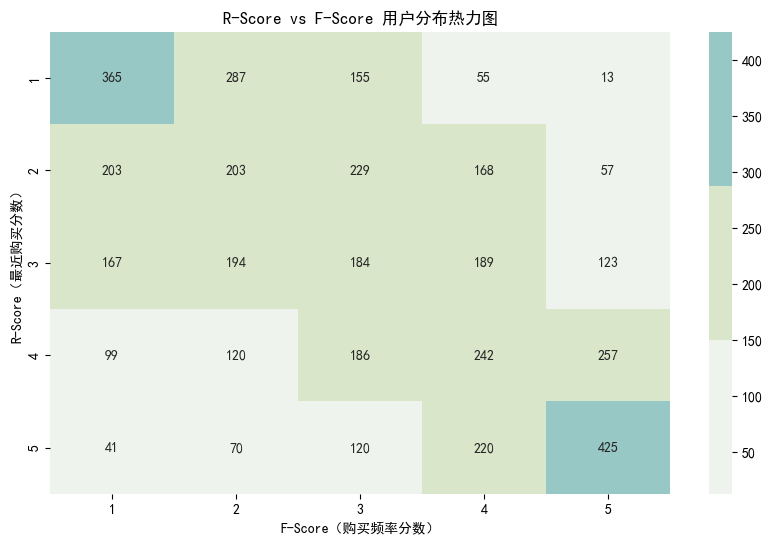

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# 可视化 RFM 结果
# 设置中文显示（避免乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows
# 当系统中使用的字体不支持 Unicode 负号字符时（例如某些中文字体，如 SimHei、微软雅黑等），默认的 Unicode 负号会显示为方块、乱码或空白。设置 False 后，改用普通减号，可以保证负号正常显示。
plt.rcParams['axes.unicode_minus'] = False  #作用是解决坐标轴上负号显示为方块或乱码的问题

# 图1：用户分层占比（饼图）
fig, axes = plt.subplots(1, 2, figsize=(12, 5)) # 参数1、2，表示1行2列

# 按用户数量占比
# 读取之前清洗好的 CSV 文件
df = pd.read_csv('../data/cleaned/online_retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'Invoice': 'nunique',  # Frequency（去重订单数）
    'TotalAmount': 'sum'   # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalAmount': 'Monetary'
})
# 使用分位数（百分位数）打分
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])  # Recency 越小分越高
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# 将分数转为数值类型
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)
def segment_customer(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return '高价值用户'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return '重点保持'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 4:
        return '重点挽留'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return '流失边缘'
    else:
        return '一般价值'
rfm['Segment'] = rfm.apply(segment_customer, axis=1)
segment_counts = rfm['Segment'].value_counts()
colors=['#B7A6C7', '#A3BDD8', '#8EBCBB', '#85B293', '#B9C18E'] # 莫兰迪色：紫、蓝、薄荷绿、绿、枯草绿
explode=[0.1,0,0,0,0]
segment_counts.plot(kind='pie', ax=axes[0], autopct='%1.1f%%', startangle=90, colors=colors, wedgeprops={'width':0.7}, explode=explode)
axes[0].set_title('用户分层占比（按用户数）')
axes[0].set_ylabel('')

# 按销售额占比
segment_monetary = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_monetary.plot(kind='bar', ax=axes[1], color='#fbeeb0') # 柱形图颜色为奶黄色
axes[1].set_title('各分层用户贡献销售额（万元）')
axes[1].set_xlabel('用户分层')
axes[1].set_ylabel('总销售额')
axes[1].tick_params(axis='x', rotation=45) # 只设置坐标轴X的刻度值参数，旋转角度为45

plt.tight_layout() # 自动优化
plt.show()

# 图2：RFM 热力图（各分数段的用户数）
rfm_heatmap = rfm.groupby(['R_Score', 'F_Score']).size().unstack(fill_value=0) # unstack将行索引转换为列索引（数据变"宽"），转换后为空的值用0填补
plt.figure(figsize=(10, 6))
mapcolors=['#eef4ed', '#d9e6c9', '#97c8c5']
sns.heatmap(rfm_heatmap, annot=True, fmt='d', cmap=mapcolors) # 显示数值标注，数值的显示格式为整数，热力图映射颜色为薄荷绿、浅绿、淡绿
plt.title('R-Score vs F-Score 用户分布热力图')
plt.xlabel('F-Score（购买频率分数）')
plt.ylabel('R-Score（最近购买分数）')
plt.show()

     Customer ID InvoiceMonth CohortMonth  CohortIndex
0        17850.0      2010-12     2010-12            1
9        13047.0      2010-12     2010-12            1
26       12583.0      2010-12     2010-12            1
46       13748.0      2010-12     2010-12            1
65       15100.0      2010-12     2010-12            1
82       15291.0      2010-12     2010-12            1
86       14688.0      2010-12     2010-12            1
105      17809.0      2010-12     2010-12            1
106      15311.0      2010-12     2010-12            1
141      14527.0      2010-12     2010-12            1
142      16098.0      2010-12     2010-12            1
155      18074.0      2010-12     2010-12            1
168      17420.0      2010-12     2010-12            1
175      16029.0      2010-12     2010-12            1
183      16250.0      2010-12     2010-12            1
197      12431.0      2010-12     2010-12            1
211      17511.0      2010-12     2010-12            1
235      1

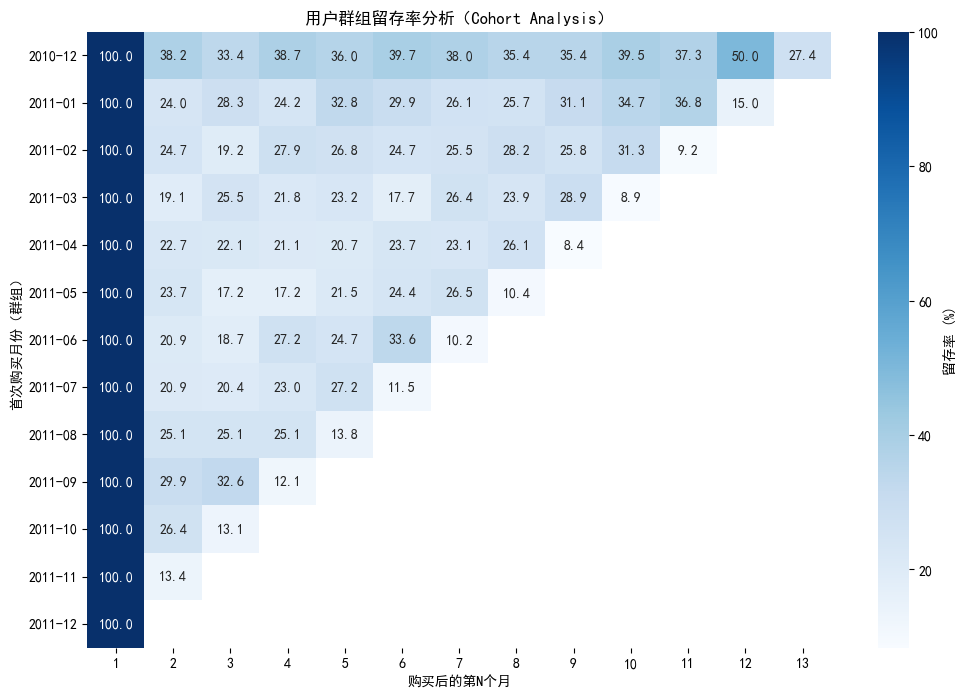

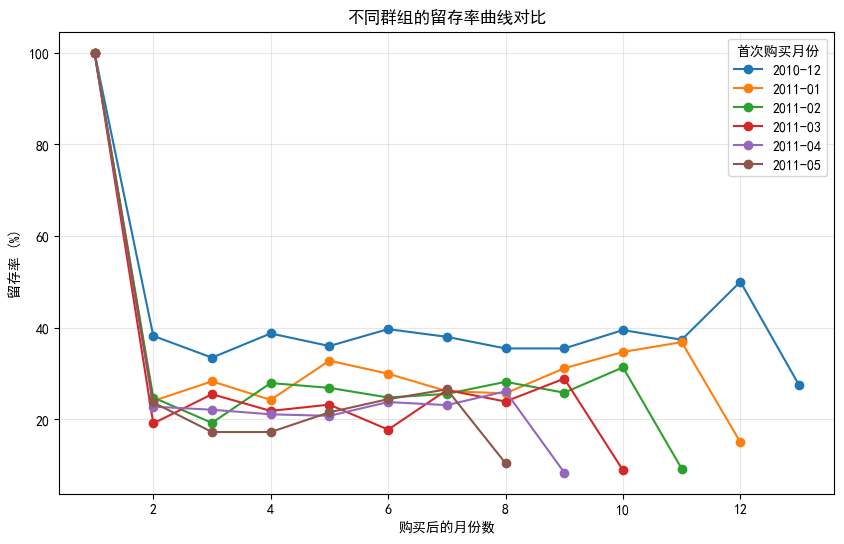

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 读取之前清洗好的 CSV 文件
df = pd.read_csv('../data/cleaned/online_retail_cleaned.csv')

# 转换日期格式
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# 设置中文显示（避免乱码）
plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows
# 当系统中使用的字体不支持 Unicode 负号字符时（例如某些中文字体，如 SimHei、微软雅黑等），默认的 Unicode 负号会显示为方块、乱码或空白。设置 False 后，改用普通减号，可以保证负号正常显示。
plt.rcParams['axes.unicode_minus'] = False  #作用是解决坐标轴上负号显示为方块或乱码的问题

# 群组留存分析 （ Cohort Analysis ）
# 这是衡量用户留存率的经典方法，用来观察不同时期首次购买的用户，在后续月份的留存表现。
# 1.准备数据
# 创建两个关键列：首次购买月份 + 当前购买月份
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')  # 转换为月份周期

# 获取每个用户的首次购买月份
# 按CustomerID分组，找到每个用户最早的购买月份
# rename('CohortMonth')：将结果Series重命名为'CohortMonth'，避免与原始列名冲突
first_purchase = df.groupby('Customer ID')['InvoiceMonth'].min().rename('CohortMonth')
# 将用户的首次购买月份关联回原表，作为新列
# 这样每个用户的所有购买记录都会带有该用户的首次购买月份
df = df.join(first_purchase, on='Customer ID')  # 关联回原表

# 计算用户在第几个月的购买（Cohort Index）
# 一行代码太长时，可以使用 \ 将代码分成多行，提高可读性。
# \ 必须放在行尾（后面不能有任何字符，包括空格），下一行的代码会紧接在上一行的后面执行，相当于把两行代码合并成一行
# 现在购买的月份减去首月购买的月份，不在同一年份就乘12转换成月份与同年份月份差相加
# 加1是为了让首次购买月份的索引为1（而不是0）
df['CohortIndex'] = (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 + \
                    (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month) + 1

# 查看结果
print(df[['Customer ID', 'InvoiceMonth', 'CohortMonth', 'CohortIndex']].drop_duplicates().head(20))

# 按群组月份和 CohortIndex 去重（每个用户每月只计一次）
# 行 = CohortMonth（用户群组，如2023-01、2023-02...）
# 列 = CohortIndex（第几个月，如1、2、3...）
# 值 = 每个群组在每个月有多少活跃用户（去重计数）
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()

# 创建留存率透视表
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')

# 计算留存率（除以第一列的值）
cohort_size = cohort_pivot.iloc[:, 0]  # 第1个月（CohortIndex=1）的用户数，即每个群组的初始用户数

# 每个群组的每个月的用户数 ÷ 该群组初始用户数 × 100
# axis=0：按行除（每行除以自己群组的初始用户数）
# 结果就是每个群组在不同月份的留存率（百分比）
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100.0

# 显示留存率矩阵
print("群组留存率矩阵（单位：%）")
print(retention_matrix.round(1))

# 绘制热力图
plt.figure(figsize=(12, 8))
sns.heatmap(retention_matrix, annot=True, fmt='.1f', cmap='Blues', 
            cbar_kws={'label': '留存率 (%)'})
plt.title('用户群组留存率分析（Cohort Analysis）')
plt.xlabel('购买后的第N个月')
plt.ylabel('首次购买月份（群组）')
plt.show()

# 绘制留存曲线（选前几个群组）
plt.figure(figsize=(10, 6))
for month in retention_matrix.index[:6]:  # 选前6个群组
    plt.plot(retention_matrix.columns, retention_matrix.loc[month], 
             marker='o', label=str(month))

plt.title('不同群组的留存率曲线对比')
plt.xlabel('购买后的月份数')
plt.ylabel('留存率 (%)')
plt.legend(title='首次购买月份')
plt.grid(True, alpha=0.3)
plt.show()

In [5]:
# 保存 RFM 结果到 CSV，供 Power BI 使用

import os

# 读取之前清洗好的 CSV 文件
df = pd.read_csv('../data/cleaned/online_retail_cleaned.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,  # Recency
    'Invoice': 'nunique',  # Frequency（去重订单数）
    'TotalAmount': 'sum'   # Monetary
}).rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalAmount': 'Monetary'
})
# 使用分位数（百分位数）打分
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])  # Recency 越小分越高
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])

# 将分数转为数值类型
rfm['R_Score'] = rfm['R_Score'].astype(int)
rfm['F_Score'] = rfm['F_Score'].astype(int)
rfm['M_Score'] = rfm['M_Score'].astype(int)

def segment_customer(row):
    if row['R_Score'] >= 4 and row['F_Score'] >= 4 and row['M_Score'] >= 4:
        return '高价值用户'
    elif row['R_Score'] >= 3 and row['F_Score'] >= 3:
        return '重点保持'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 4:
        return '重点挽留'
    elif row['R_Score'] <= 2 and row['F_Score'] <= 2:
        return '流失边缘'
    else:
        return '一般价值'
rfm['Segment'] = rfm.apply(segment_customer, axis=1)
segment_counts = rfm['Segment'].value_counts()
segment_monetary = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
segment_monetary_pct = segment_monetary / segment_monetary.sum() * 100.0

rfm = rfm.reset_index()
rfm.to_csv('../data/cleaned/rfm_analysis_results.csv', index=False, encoding='utf-8-sig')
print("已保存到 ../data/cleaned/rfm_analysis_results.csv")

# 输出关键结论
print("=" * 50)
print("RFM 分析核心结论")
print("=" * 50)
print(f"1. 高价值用户数量: {(rfm['Segment'] == '高价值用户').sum()} 人")
print(f"   贡献销售额占比: {segment_monetary_pct['高价值用户']:.1f}%")

print(f"\n2. 一般价值用户数量: {(rfm['Segment'] == '一般价值').sum()} 人")
print(f"   贡献销售额占比: {segment_monetary_pct['一般价值']:.1f}%")

print(f"\n3. 流失边缘用户数量: {(rfm['Segment'] == '流失边缘').sum()} 人")
print(f"   贡献销售额占比: {segment_monetary_pct['流失边缘']:.1f}%")

print(f"\n4. 重点保持用户数量: {(rfm['Segment'] == '重点保持').sum()} 人")
print(f"   贡献销售额占比: {segment_monetary_pct['重点保持']:.1f}%")

print(f"\n5. 重点挽留用户数量: {(rfm['Segment'] == '重点挽留').sum()} 人")
print(f"   贡献销售额占比: {segment_monetary_pct['重点挽留']:.1f}%")

# 留存分析
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
first_purchase = df.groupby('Customer ID')['InvoiceMonth'].min().rename('CohortMonth')
df = df.join(first_purchase, on='Customer ID')
df['CohortIndex'] = (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 + \
                    (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month) + 1
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['Customer ID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='Customer ID')
cohort_size = cohort_pivot.iloc[:, 0]
retention_matrix = cohort_pivot.divide(cohort_size, axis=0) * 100.0

# 计算平均留存率
avg_retention = retention_matrix.mean(axis=0)
print("\n" + "=" * 50)
print("留存率分析核心结论")
print("=" * 50)
for month in retention_matrix.columns:
    print(f"第 {month} 个月平均留存率: {avg_retention[month]:.1f}%")

# 计算每个月之间的留存率下降幅度
retention_drop = retention_matrix.diff(axis=1)  # 计算相邻列的差值（负数表示下降）
# 找出下降幅度最大的月份区间（排除第1列，因为第1列没有前一个月）
max_drop_idx = retention_drop.iloc[:, 1:].mean().idxmin()  # 平均下降最多的列，因为比较的是负数所以最小即最大负值，1是指首月和第二个月之间的区间
# 找出对应的是哪两个月之间
from_month = max_drop_idx - 1
to_month = max_drop_idx
print(f"\n用户流失最快发生在第 {from_month} 个月到第 {to_month} 个月之间")

已保存到 ../data/cleaned/rfm_analysis_results.csv
RFM 分析核心结论
1. 高价值用户数量: 976 人
   贡献销售额占比: 70.5%

2. 一般价值用户数量: 1075 人
   贡献销售额占比: 6.8%

3. 流失边缘用户数量: 1058 人
   贡献销售额占比: 4.0%

4. 重点保持用户数量: 970 人
   贡献销售额占比: 13.0%

5. 重点挽留用户数量: 293 人
   贡献销售额占比: 5.6%

留存率分析核心结论
第 1 个月平均留存率: 100.0%
第 2 个月平均留存率: 24.1%
第 3 个月平均留存率: 23.2%
第 4 个月平均留存率: 23.8%
第 5 个月平均留存率: 25.2%
第 6 个月平均留存率: 25.7%
第 7 个月平均留存率: 25.1%
第 8 个月平均留存率: 24.9%
第 9 个月平均留存率: 25.9%
第 10 个月平均留存率: 28.6%
第 11 个月平均留存率: 27.8%
第 12 个月平均留存率: 32.5%
第 13 个月平均留存率: 27.4%

用户流失最快发生在第 1 个月到第 2 个月之间
